# Exercise 4 — Golden Section Search

## Theory

The Golden Section Search is an optimization method used to find the maximum or minimum of a unimodal function within a given interval without using derivatives.

For this problem, the objective is to maximize the area function

$$
A(\theta)=4\sin(\theta)(1+\cos(\theta)).
$$

Starting with an interval $[x_l,x_u]$ that contains the maximum, the golden ratio factor is defined as

$$
\phi=\frac{\sqrt{5}-1}{2}.
$$

The distance between the intermediate points and the boundaries is

$$
d=\phi(x_u-x_l).
$$

The two intermediate points are then calculated as

$$
x_1=x_l+d,
$$

$$
x_2=x_u-d.
$$

The function is evaluated at both points:

$$
f_1=A(x_1),
\qquad
f_2=A(x_2).
$$

For a maximization problem, if

$$
f(x_1)>f(x_2),
$$

the interval is updated by setting

$$
x_l=x_2,
\qquad
x_2=x_1,
$$

and a new value of $x_1$ is calculated.

On the other hand, if

$$
f(x_1)<f(x_2),
$$

the interval is updated by setting

$$
x_u=x_1,
\qquad
x_1=x_2,
$$

and a new value of $x_2$ is calculated.

This process is repeated until the interval satisfies the tolerance criterion

$$
|x_u-x_l|<\epsilon.
$$

The position of the maximum can then be approximated by

$$
\theta_{\mathrm{opt}}=\frac{x_l+x_u}{2}.
$$

In [2]:
import numpy as np

# Funcion de area
def area(theta):
  return 4*np.sin(theta)*(1+np.cos(theta))

# Parametros
x_l = 0
x_u = np.pi/2
epsilon = 0.05

phi = (np.sqrt(5)-1)/2
d = phi*(x_u-x_l)

x1 = x_l+d
x2 = x_u-d

f1 = area(x1)
f2 = area(x2)
iteracion = 0

while abs(x_u-x_l) >= epsilon:

  iteracion = iteracion+1

  if f1 > f2:

    x_l = x2
    x2 = x1
    f2 = f1

    d = phi*(x_u-x_l)
    x1 = x_l+d
    f1 = area(x1)

  else:

    x_u = x1
    x1 = x2
    f1 = f2

    d = phi*(x_u-x_l)
    x2 = x_u-d
    f2 = area(x2)
theta_opt = (x_l+x_u)/2
area_max = area(theta_opt)

print("Iteraciones:",iteracion)
print("Theta optimo:",theta_opt)
print("Area maxima:",area_max)

Iteraciones: 8
Theta optimo: 1.0416248275772215
Area maxima: 5.195990883093555


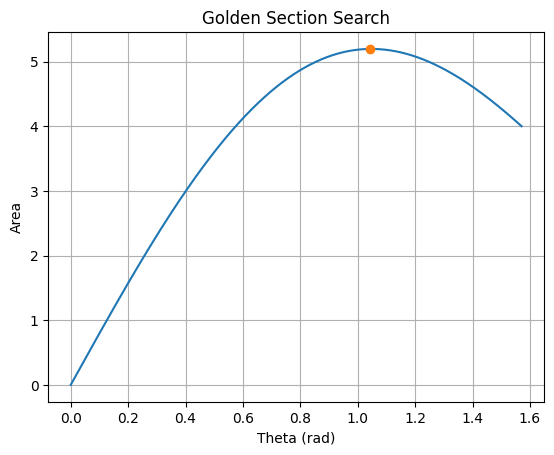

In [3]:
import matplotlib.pyplot as plt

theta = np.linspace(0,np.pi/2,1000)
A = area(theta)

plt.plot(theta,A)
plt.plot(theta_opt,area_max,'o')

plt.xlabel("Theta (rad)")
plt.ylabel("Area")
plt.title("Golden Section Search")
plt.grid()

plt.show()

## Conclusion

The Golden Section Search was used to determine the value of $\theta$ that maximizes the area function

$$
A(\theta)=4\sin(\theta)(1+\cos(\theta)).
$$

The method progressively reduces the initial search interval by comparing the function at two intermediate points. At each iteration, the portion of the interval that cannot contain the maximum is discarded.

The algorithm stops when the width of the search interval becomes smaller than the specified tolerance $\epsilon$. The optimal angle is then approximated using the midpoint of the final interval.

This method allows the maximum to be found numerically without calculating derivatives of the objective function.